# Statistical & Risk Flag Feature Engineering
**Author:** Shais Daimi  
**Branch:** dev/shais  
**Depends on:** Physical features 

This notebook calls two functions from `statistical_and_risk_flag_analysis.py`:
- `create_statistical_features(df)` — Z-Score features
- `create_risk_flag_features(df)` — Binary risk flag features

## 1. Imports

In [1]:
import pandas as pd

# Import our two functions from the .py file
from statistical_and_risk_flag_analysis import (
    create_statistical_features,
    create_risk_flag_features
)

print('Imports done')

# to handle input file(s)
from pathlib import Path

Imports done


## 2. Load Dataset & Build Physics Features

In [2]:
# csv file path (to resolve problem at production level)
BASE_DIR = Path().resolve().parent
df = pd.read_csv(BASE_DIR / 'Dataset' / 'ai4i2020.csv')

# Rename columns for easier use
df.rename(columns={
    'Air temperature [K]'     : 'air_temp',
    'Process temperature [K]' : 'process_temp',
    'Rotational speed [rpm]'  : 'rpm',
    'Torque [Nm]'             : 'torque',
    'Tool wear [min]'         : 'tool_wear'
}, inplace=True)

# Physics features
df['power']           = df['torque'] * df['rpm']
df['temp_diff']       = df['process_temp'] - df['air_temp']
df['wear_rate']       = df['tool_wear'] / (df['rpm'] + 1)
df['torque_per_wear'] = df['torque'] / (df['tool_wear'] + 1)
df['strain_index']    = df['torque'] * df['tool_wear']
df['power_per_temp']  = df['power'] / df['process_temp']

print('Dataset loaded')
print('Shape:', df.shape)
df.head()

Dataset loaded
Shape: (10000, 20)


,UDI,Product ID,Type,air_temp,process_temp,rpm,torque,tool_wear,Machine failure,TWF,HDF,PWF,OSF,RNF,power,temp_diff,wear_rate,torque_per_wear,strain_index,power_per_temp
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,66382.8,10.5,0.000000,42.800000,0.0,215.109527
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,65190.4,10.5,0.002129,11.575000,138.9,211.177195
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,74001.2,10.4,0.003336,8.233333,247.0,239.874230
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,56603.5,10.4,0.004881,4.937500,276.5,183.420285
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,56320.0,10.5,0.006388,4.000000,360.0,182.442501


## 3. Create Statistical Features (Z-Scores)

Z-SCORE FEATURES CREATED
  Feature                       Mean      Std   Extreme (>3σ)
  ----------------------------------------------------------
  rpm_zscore                   -0.00     1.00             164
  torque_zscore                 0.00     1.00              25
  power_zscore                  0.00     1.00              30
  wear_zscore                   0.00     1.00               0
  temp_diff_zscore              0.00     1.00               0


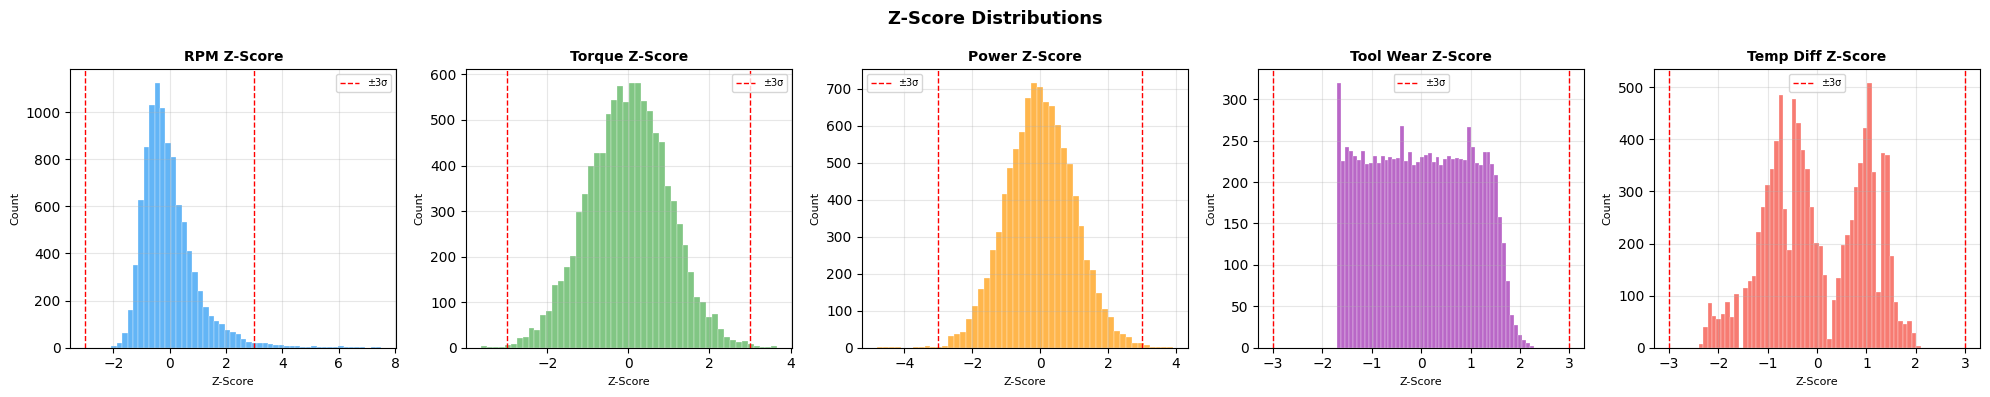


Plot saved: zscore_distributions.png


In [3]:
df = create_statistical_features(df)

## 4. Create Risk Flag Features

RISK FLAG FEATURES CREATED
  Flag                       Flagged   % Data  Actual Fail  Precision
  ------------------------------------------------------------------
  high_wear_flag                 762     7.6%          118        15%
  high_torque_flag               236     2.4%           99        42%
  low_rpm_flag                  1847    18.5%          236        13%
  high_temp_flag                   0     0.0%            0         0%
  power_anomaly_flag             453     4.5%          130        29%


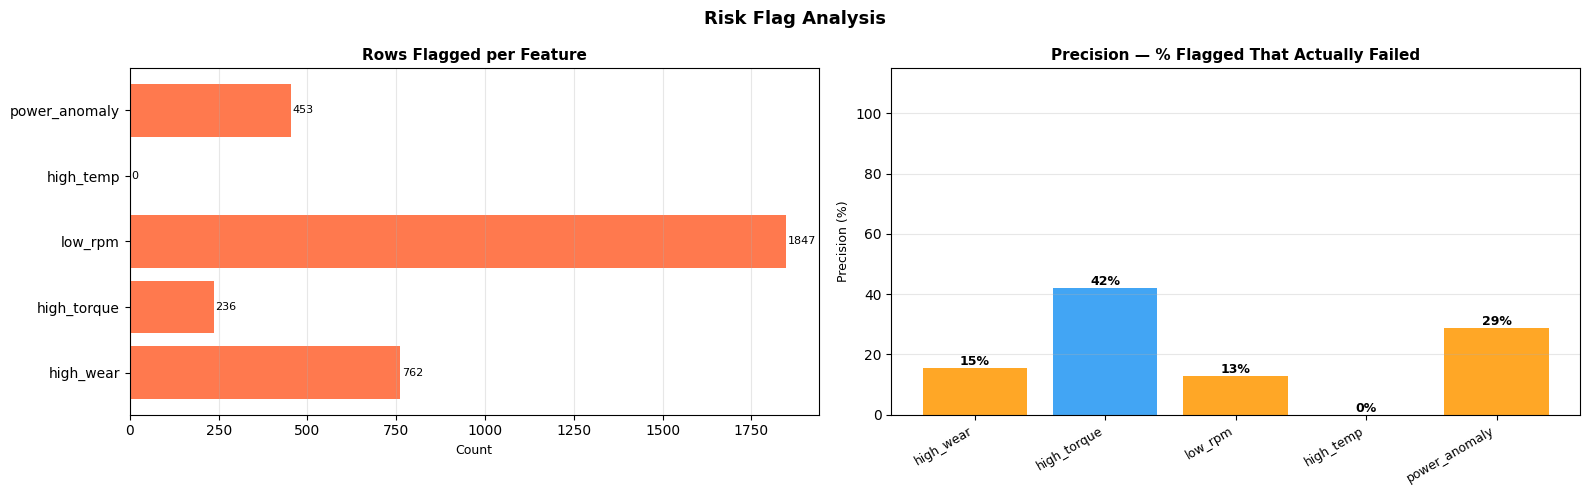


Plot saved: risk_flags_analysis.png


In [4]:
df = create_risk_flag_features(df)

## 5. Final Output

In [5]:
print(f'Total columns in enriched dataset: {len(df.columns)}')
print(f'New features added: 10 (5 z-scores + 5 risk flags)')

new_cols = [
    'rpm_zscore', 'torque_zscore', 'power_zscore', 'wear_zscore', 'temp_diff_zscore',
    'high_wear_flag', 'high_torque_flag', 'low_rpm_flag', 'high_temp_flag', 'power_anomaly_flag'
]

df[new_cols].head()

Total columns in enriched dataset: 30
New features added: 10 (5 z-scores + 5 risk flags)


,rpm_zscore,torque_zscore,power_zscore,wear_zscore,temp_diff_zscore,high_wear_flag,high_torque_flag,low_rpm_flag,high_temp_flag,power_anomaly_flag
0,0.068182,0.282186,0.629412,-1.695899,0.498824,0,0,0,0,0
1,-0.729435,0.633276,0.512431,-1.648769,0.498824,0,0,0,0,0
2,-0.227438,0.944242,1.376820,-1.617349,0.398934,0,0,0,0,0
3,-0.589992,-0.048843,-0.329993,-1.585930,0.398934,0,0,0,0,0
4,-0.729435,0.001313,-0.357806,-1.554510,0.498824,0,0,0,0,0
